In [1]:
import math
import importlib

from librosa.feature import spectral_flatness

import AFE_.featureExtractor as afe
import AFE_.extractor as afeD
importlib.reload(afe)
importlib.reload(afeD)

y, sr = afe.load_audio("../audioSamples/teste2.wav")


mfcc = afe.extract_lfcc(y, sr)
mfcc.shape

mfcc = afe.extract_lfcc(y, sr)
cqcc = afe.extract_cqcc(y, sr)
lfcc = afe.extract_lfcc(y, sr)
lfo = afe.extract_lfo(y, sr)
zcr = afe.extract_zcr(y, sr)
pitch = afe.extract_pitch(y)
rplp = afe.extract_rplp(y, sr)

cqcc.shape, mfcc.shape, lfcc.shape, lfo.shape, zcr.shape, pitch.shape, rplp.shape


/home/alex/miniconda3/envs/AudioTransformers/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


((442, 13), (442, 13), (442, 13), (1, 445), (1, 445), (158,), (442, 13))

In [2]:
import AFE_.extractor as afeEx
import tqdm as notebook_tqdm
# Criando um extrator para o modelo Wav2Vec2
audio_feature_extractor = afeEx.AudioFeatureExtractor("facebook/wav2vec2-large-960h")

# Caminho para o arquivo de áudio
file_path = "/DATA2/DATASET_DF/FakeOrReal/for-original/for-original/training/real/file1.wav"

# Extraindo as características
features = audio_feature_extractor.extract_features(file_path)

print("Características extraídas para Wav2Vec2:")
print(features.shape)  # Exibe o tamanho das características extraídas


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Características extraídas para Wav2Vec2:
(133, 1024)


In [3]:
features = audio_feature_extractor.extract_features(file_path)
print(features.shape)

(133, 1024)


In [4]:
from AFE_.models import AudioFeatureExtractor

model_names = {
    # "Wav2Vec2": "facebook/wav2vec2-base-960h",
    # "WavLM": "microsoft/wavlm-base",
    # "HuBERT": "facebook/hubert-base-ls960",
    "Data2Vec": "facebook/data2vec-audio-base-960h"
}

# file_path = "../audioSamples/teste2_16k.wav"
# file_path = "/DATA2/DATASET_DF/SceneFake/dev/fake/B_2548_10_A.wav"
# file_path = "/DATA2/DATASET_DF/SceneFake/train/fake/A_13540_05_D.wav"
file_path = "/DATA2/DATASET_DF/SceneFake/train/fake/A_13531_15_D.wav"
for name, model_name in model_names.items():
    print(f"\nExtraindo com {name}...")
    extractor = AudioFeatureExtractor(model_name)
    features = extractor.extract_features(file_path)
    print(f"{name} - Shape das features extraídas: {features.shape}")



Extraindo com Data2Vec...
Data2Vec - Shape das features extraídas: (231, 768)


In [5]:
from AFE_ import waveletFeatureExtractor as wfe
import importlib
importlib.reload(wfe)

# Exemplo de uso
audio_path = file_path
features = wfe.extract_feature_frames_by_subband(file_path, feature_name="kurtosis", level=5)
# print("Shape das características extraídas:", features.shape)

features.shape

(461, 32)

In [6]:
import librosa

# Caminho do áudio
audio_path = file_path

# Carregamento mono e com sample rate fixo
signal, sr = librosa.load(audio_path, sr=16000, mono=True)


In [21]:
import importlib
# from AFEW.extractors.classic import load_audio
from AFEW.audio_utils import load_audio
# importlib.reload(load_audio)

y, sr = load_audio(file_path)
print("Sinal:", y.shape, "| Sample rate:", sr)

from AFEW.extractors.classic import extract_mfcc

mfccs, delta, delta2 = extract_mfcc(y, sr)
print("MFCC:", mfccs.shape)
print("Delta MFCC:", delta.shape)
print("Delta² MFCC:", delta2.shape)

delta2

Sinal: (74080,) | Sample rate: 16000
MFCC: (464, 13)
Delta MFCC: (464, 13)
Delta² MFCC: (464, 13)


array([[ 1.2096537 , -0.8550269 ,  0.6768089 , ..., -0.51307577,
         0.14937134,  0.21249437],
       [ 1.2096537 , -0.8550269 ,  0.6768089 , ..., -0.51307577,
         0.14937134,  0.21249437],
       [ 1.2096537 , -0.8550269 ,  0.6768089 , ..., -0.51307577,
         0.14937134,  0.21249437],
       ...,
       [ 0.41839367, -1.0230609 , -1.3655585 , ..., -1.0554866 ,
        -0.8014764 , -0.56060815],
       [ 0.41839367, -1.0230609 , -1.3655585 , ..., -1.0554866 ,
        -0.8014764 , -0.56060815],
       [ 0.41839367, -1.0230609 , -1.3655585 , ..., -1.0554866 ,
        -0.8014764 , -0.56060815]], dtype=float32)

In [12]:
from AFEW.extractors.classic import extract_cqcc

cqcc_feat = extract_cqcc(y, sr)
print("CQCC:", cqcc_feat.shape)


CQCC: (461, 13)


In [13]:
from AFEW.extractors.classic import extract_lfo

lfo = extract_lfo(y, sr)
print("LFO (RMS Energy):", lfo.shape)


LFO (RMS Energy): (1, 464)


In [14]:
from AFEW.extractors.classic import extract_pitch

pitch = extract_pitch(file_path)
print("Pitch F0:", pitch.shape)
print("F0 (amostras iniciais):", pitch[:10])


Pitch F0: (460,)
F0 (amostras iniciais): [nan nan nan nan nan nan nan nan nan nan]


In [15]:
from AFEW.extractors.classic import extract_lfcc

lfcc_feat = extract_lfcc(y, sr)
print("LFCC:", lfcc_feat.shape)


LFCC: (461, 13)


In [16]:
from AFEW.extractors.classic import extract_rplp

rplp_feat = extract_rplp(y, sr)
print("RPLP:", rplp_feat.shape)


RPLP: (461, 13)


In [17]:
from AFEW.extractors.classic import extract_zcr

zcr = extract_zcr(y, sr)
print("ZCR:", zcr.shape)


ZCR: (1, 464)


In [11]:
import joblib

mfccFeature = joblib.load("/DATA2/DATASET_DF/SceneFake/train/features/mfcc_real_fake_features.joblib")

In [21]:
import numpy as np
(np.vstack(mfccFeature['fake'])).shape

(4494, 39)

In [2]:
import joblib
WAVLM = joblib.load("/DATA2/DATASET_DF/SceneFake/train/features/wavlm_base_real_fake_features.joblib")

In [9]:
len(WAVLM['real'][1])

768

In [24]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

fs = 1024
t = np.linspace(0, 1, fs, endpoint=False)
signal = np.sin(50 * 2 * np.pi * t) + np.sin(120 * 2 * np.pi * t) + 0.5 * np.random.randn(fs)

# Configuração do Wavelet Packet
wavelet = 'db4'
max_level = 5

# Decomposição
wp = pywt.WaveletPacket(data=signal, wavelet=wavelet, mode='symmetric', maxlevel=max_level)



In [51]:
# for node in wp.get_level(5, 'natural'):
#     print(node.path)
#

wp.get_level(5)[31].data

array([-0.10353277, -0.30032357, -0.14513823,  0.37629498,  0.66939513,
       -0.73835276,  0.08051405, -0.03050451, -0.27246288,  0.66504906,
       -0.61666063,  0.1020852 ,  1.08789125, -0.18530117, -0.4707268 ,
        0.36415749,  0.42374698,  0.06699208, -0.48377145, -0.33605224,
       -0.25310582, -0.04160855, -0.09750257,  0.3651546 ,  0.22497393,
        0.40019762, -0.5834672 , -0.10560597,  0.28773354, -0.7364633 ,
        0.24604978, -0.29502986, -0.38609855, -0.00472972,  0.0417792 ,
       -0.014292  , -0.03505836,  0.14869269])

Shape das features extraídas: (221, 96)
Exemplo de vetor de features para um frame:
[4.0061167e-03 4.2677631e+00 4.7391790e-01 4.7277454e-03 3.9825578e+00
 7.4163711e-01 1.0648774e-03 3.9559355e+00 3.3293501e-01 3.2491405e-03
 3.9237232e+00 4.7312695e-01 2.3824093e-04 3.9751346e+00 6.2108487e-01
 2.0544227e-04 4.3397727e+00 3.0820709e-01 5.0837744e-04 3.9779232e+00
 7.3793262e-01 4.5327932e-04 3.8203609e+00 6.1374456e-01 1.8730801e-05
 4.1318078e+00 7.3604143e-01 2.4514236e-05 4.0844145e+00 6.4944291e-01
 3.1495310e-05 4.0989876e+00 3.4062046e-01 3.0793606e-05 4.2294044e+00
 7.2993165e-01 6.9365742e-05 4.2429562e+00 5.2943915e-01 9.8046075e-05
 4.2468500e+00 6.1980903e-01 5.8300280e-05 4.1417246e+00 6.2872428e-01
 7.6517455e-05 4.1811523e+00 7.3788989e-01 1.2727216e-06 3.8330114e+00
 5.7533950e-01 3.6276826e-06 4.3990908e+00 4.0846735e-01 7.5999033e-06
 4.1304021e+00 5.7092035e-01 8.0061245e-06 3.9955618e+00 7.1075577e-01
 1.9569916e-05 4.1977701e+00 8.0918521e-01 7.8707099e-06 4.32008

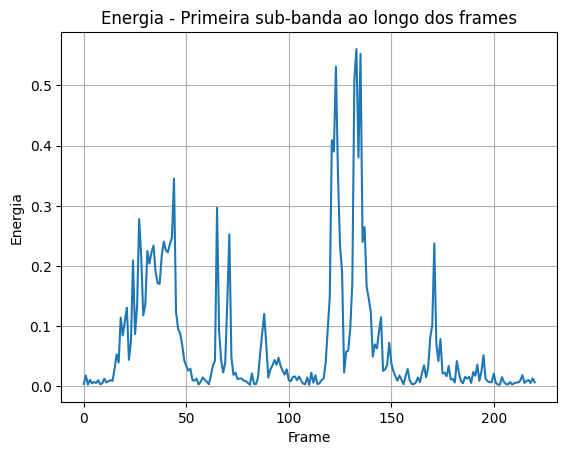

In [35]:
import matplotlib.pyplot as plt
from AFEW.audio_utils import load_audio
import AFEW.extractors.wavelet as wv
import importlib
importlib.reload(wv)

# Caminho do seu arquivo de áudio
audio_path = "/DATA2/MyWorkspaces/PyWorkspaces/AudioTransformers/audioSamples/teste2.wav"

# Carregar o áudio
signal, sample_rate = load_audio(audio_path)

# Instanciar o extrator — Modo por frame (30 ms, overlap 10 ms)
extractor = wv.WaveletPacketFeatureExtractor(
    wavelet='coif2',
    level=5,
    features=['energy', 'entropy', 'spectral_flatness'],
    mode='frame',             # Processamento por janelas de tempo
    frame_size_ms=30,
    frame_overlap_ms=10
)

# Extrair as features
features = extractor.extract(signal, sample_rate)

print(f"Shape das features extraídas: {features.shape}")
print(f"Exemplo de vetor de features para um frame:\n{features[0]}")

# Opcional: visualizar a evolução de uma feature ao longo dos frames
plt.plot(features[:, 0])  # Exemplo: energia da primeira sub-banda
plt.title("Energia - Primeira sub-banda ao longo dos frames")
plt.xlabel("Frame")
plt.ylabel("Energia")
plt.grid(True)
plt.show()


In [36]:
features = extractor.extract(signal, sample_rate)

In [37]:
features

array([[4.0061167e-03, 4.2677631e+00, 4.7391790e-01, ..., 1.3646743e-05,
        4.0605097e+00, 5.6404251e-01],
       [1.8063925e-02, 4.0061498e+00, 4.4988877e-01, ..., 1.4767326e-05,
        4.2397714e+00, 6.5584677e-01],
       [2.9299215e-03, 4.3953571e+00, 7.0034641e-01, ..., 1.6680857e-05,
        4.2252898e+00, 4.2499357e-01],
       ...,
       [5.7495134e-03, 4.2943316e+00, 4.0353498e-01, ..., 1.1435545e-05,
        4.2637048e+00, 7.6738900e-01],
       [1.3455425e-02, 4.0843921e+00, 4.1504091e-01, ..., 1.2168161e-05,
        3.9460471e+00, 5.8246958e-01],
       [6.7124926e-03, 4.2317767e+00, 4.1803214e-01, ..., 9.0179883e-06,
        4.1924686e+00, 6.3004661e-01]], dtype=float32)

In [44]:
import pywt
pywt.wavelist('haar')

['haar']

In [58]:
import joblib

features = joblib.load("/DATA2/DATASET_DF/SceneFake/train/features/wavelet_haar_L5_real_fake_features.joblib")

In [72]:
features['real'][6].shape

(146, 160)

In [80]:
pywt.wavelist('coif')

['coif1',
 'coif2',
 'coif3',
 'coif4',
 'coif5',
 'coif6',
 'coif7',
 'coif8',
 'coif9',
 'coif10',
 'coif11',
 'coif12',
 'coif13',
 'coif14',
 'coif15',
 'coif16',
 'coif17']